In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (13, 5)
sns.set_style('whitegrid')

# ── UPDATE THIS PATH ──────────────────────────────────────────────────────────
RAW_DATA_PATH = r'C:\Users\Rishit\Desktop\O2R-Order-prediction\data\Jan - May '2'
# ─────────────────────────────────────────────────────────────────────────────

print('Libraries loaded.')

Libraries loaded.


In [4]:
df = pd.read_csv(RAW_DATA_PATH)
df['createdAt'] = pd.to_datetime(df['createdAt'], dayfirst=True)
print(f'Shape         : {df.shape}')
print(f'Total rows    : {len(df):,}')
print(f'Columns       : {df.shape[1]}')
print(f'Date range    : {df["createdAt"].min().date()}  →  {df["createdAt"].max().date()}')
print(f'Total days    : {(df["createdAt"].max() - df["createdAt"].min()).days + 1}')
df.head(3)

Shape         : (609723, 30)
Total rows    : 609,723
Columns       : 30
Date range    : 2026-01-01  →  2026-05-31
Total days    : 151


,createdAt,deliveryDate,orderTime,orderNumber,callingAgentId,callingAgentName,hubId,hubName,customerId,shopType,...,deliveredQty,deliveredTime,orderStatus,skuStatus,orderToDeliveryTime,deliveryTimeSlot,cancellationReason,brand,category,subCategory
0,2026-01-31,02-02-2026,23:55:02,26013101482,NaN,NaN,HB011,Rapid Enterprises,USR-169747,General B,...,1,02-02-2026 16:42,Delivered,DELIVERED,"1 days, 16 hours, 47 minutes",02-02-2026 09:00,NaN,Rajnigandha,Pan Masala,Premium Pan Masala
1,2026-01-31,02-02-2026,23:46:26,26013101481,NaN,NaN,HB011,Rapid Enterprises,USR-169429,Wholesaler,...,0,NaN,CANCELLED,NaN,"1 days, 12 hours, 13 minutes",02-02-2026 12:00,Could not locate shop,Bongchie,Smoking Accessories,Rolling Paper
2,2026-01-31,02-02-2026,23:46:26,26013101481,NaN,NaN,HB011,Rapid Enterprises,USR-169429,Wholesaler,...,0,NaN,CANCELLED,NaN,"1 days, 12 hours, 13 minutes",02-02-2026 12:00,Could not locate shop,Hell Energy Drink,Beverage,Energy Drinks


In [5]:
null_df = pd.DataFrame({
    'dtype'     : df.dtypes,
    'null_count': df.isnull().sum(),
    'null_%'    : (df.isnull().sum() / len(df) * 100).round(2)
})
print('=== ALL COLUMNS ===')
print(null_df.to_string())

=== ALL COLUMNS ===
                              dtype  null_count  null_%
createdAt            datetime64[ns]           0    0.00
deliveryDate                 object           0    0.00
orderTime                    object           0    0.00
orderNumber                   int64           0    0.00
callingAgentId               object      341173   55.96
callingAgentName             object      341173   55.96
hubId                        object           0    0.00
hubName                      object           0    0.00
customerId                   object           0    0.00
shopType                     object           0    0.00
retailerType                 object        2546    0.42
orderSource                  object           0    0.00
skuNumber                    object           0    0.00
productType                  object           0    0.00
itemName                     object           0    0.00
unitType                    float64      609723  100.00
unitWeight                  

In [6]:
for col in ['orderStatus', 'orderSource', 'shopType', 'retailerType']:
    print(f'\n=== {col} ===')
    vc = df[col].value_counts()
    pct = (vc / len(df) * 100).round(1)
    print(pd.DataFrame({'count': vc, '%': pct}).to_string())


=== orderStatus ===
                     count     %
orderStatus                     
Delivered           391923  64.3
PartiallyDelivered  151207  24.8
CANCELLED            66286  10.9
Created                288   0.0
BatchAssigned           14   0.0
Dispatched               5   0.0

=== orderSource ===
                count     %
orderSource                
App            341161  56.0
CALLING_AGENT  268550  44.0
SUPER_ADMIN        12   0.0

=== shopType ===
             count     %
shopType                
Paan B      207785  34.1
General A   134777  22.1
General B    94164  15.4
General C    90649  14.9
Paan A       49995   8.2
Paan C       25628   4.2
Wholesaler    2668   0.4
Chemist B     1438   0.2
Chemist A     1436   0.2
Chemist C     1183   0.2

=== retailerType ===
               count     %
retailerType              
HVHF          488637  80.1
HVLF          114584  18.8
LVLF            3717   0.6
LVHF             239   0.0


In [7]:
print('=== HUB NAME (Top 20) ===')
print(df['hubName'].value_counts().head(20).to_string())

=== HUB NAME (Top 20) ===
hubName
Instant Foods(Noida)             134655
Instant Foods (SED)               77274
Rapid Enterprises                 63725
Instant Foods (GZB)               62078
Crossline Events (Meerut)         53796
Crossline Events (Noida)          53597
Cross Line Events (Ghaziabad)     50273
Cross Line Events (EDelhi)        49241
NB Enterprises (West Delhi)       36695
Instant Foods (Mathura)           26602
Maa Sharda(LKO)                    1750
Maa Sharda                           37


In [8]:
confirmed = df[df['orderStatus'].isin(['Delivered', 'PartiallyDelivered'])]
orders    = confirmed.drop_duplicates(subset='orderNumber')[[
    'orderNumber','customerId','createdAt',
    'hubName','shopType','retailerType','orderSource'
]].copy()

print(f'Confirmed SKU rows      : {len(confirmed):,}')
print(f'Unique confirmed orders : {len(orders):,}')
print(f'Unique active retailers : {orders["customerId"].nunique():,}')
print(f'Cancellation rate       : {(df["orderStatus"]=="CANCELLED").sum() / df["orderNumber"].nunique() * 100:.1f}%')

Confirmed SKU rows      : 543,130
Unique confirmed orders : 177,340
Unique active retailers : 8,640
Cancellation rate       : 33.1%


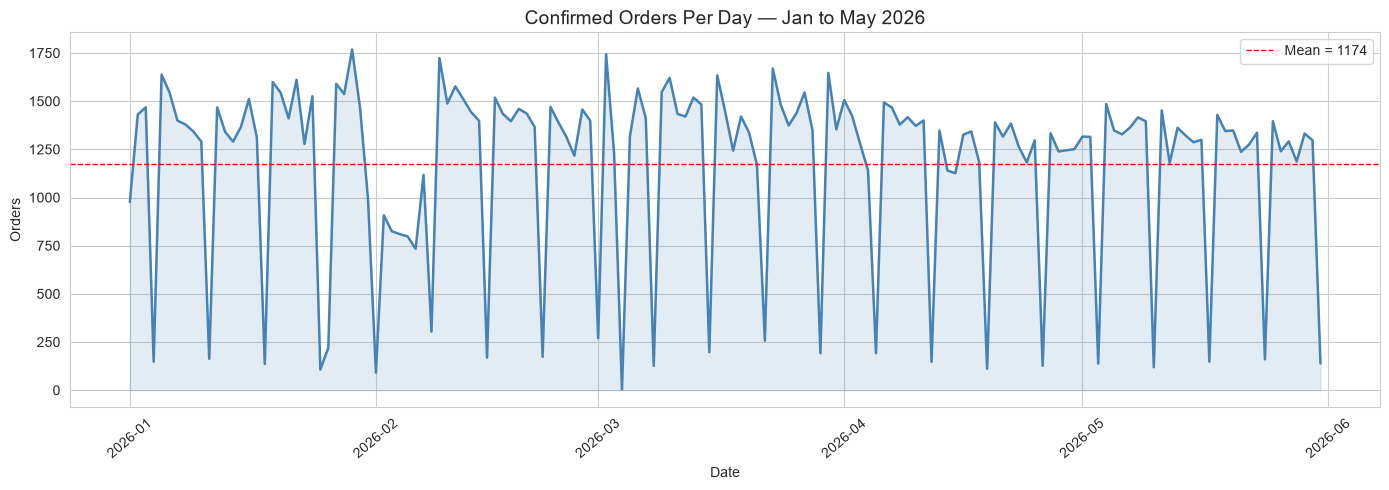

Avg orders/day : 1174
Min            : 4
Max            : 1768


In [9]:
daily = orders.groupby(orders['createdAt'].dt.date)['orderNumber'].count().reset_index()
daily.columns = ['date', 'orders']

plt.figure(figsize=(14, 5))
plt.plot(daily['date'], daily['orders'], color='steelblue', lw=1.8)
plt.fill_between(daily['date'], daily['orders'], alpha=0.15, color='steelblue')
plt.axhline(daily['orders'].mean(), color='red', lw=1, linestyle='--',
            label=f'Mean = {daily["orders"].mean():.0f}')
plt.title('Confirmed Orders Per Day — Jan to May 2026', fontsize=14)
plt.xlabel('Date'); plt.ylabel('Orders')
plt.legend(); plt.xticks(rotation=40); plt.tight_layout(); plt.show()

print(f'Avg orders/day : {daily["orders"].mean():.0f}')
print(f'Min            : {daily["orders"].min()}')
print(f'Max            : {daily["orders"].max()}')

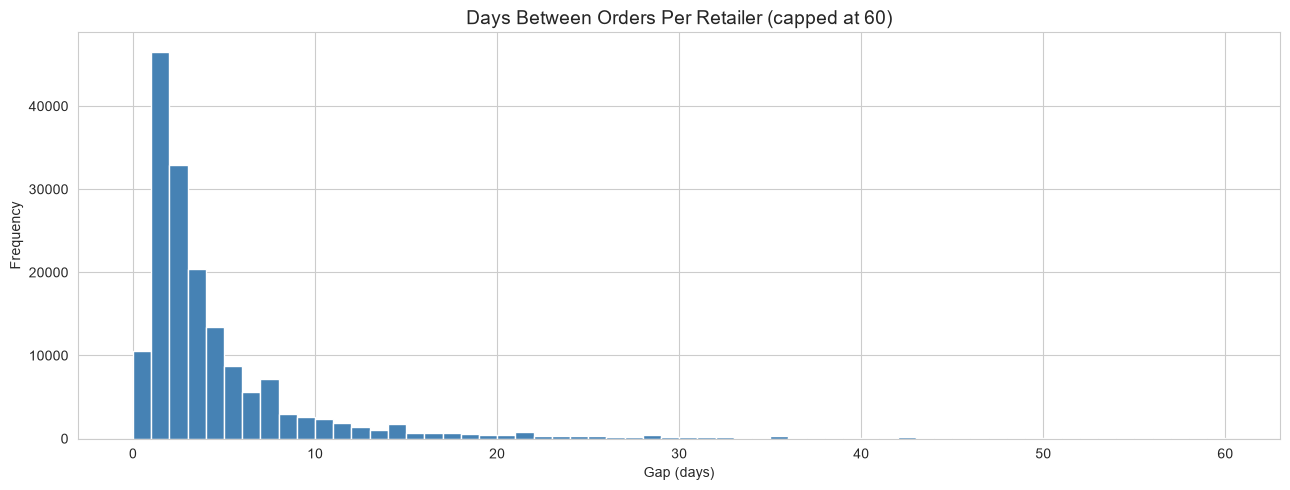

=== GAP STATS ===
count    168700.000000
mean          4.583942
std           7.629959
min           0.000000
25%           1.000000
50%           2.000000
75%           5.000000
max         147.000000

Gap ≤ 1 day  : 56,998  (32.1%)
Gap 2-3 days : 53,361
Gap 4-7 days : 34,937
Gap > 7 days : 23,404


In [10]:
o = orders.sort_values(['customerId','createdAt'])
o['gap'] = o.groupby('customerId')['createdAt'].diff().dt.days
gaps = o[o['gap'].notna() & (o['gap'] <= 60)]

plt.figure(figsize=(13, 5))
plt.hist(gaps['gap'], bins=60, color='steelblue', edgecolor='white')
plt.title('Days Between Orders Per Retailer (capped at 60)', fontsize=14)
plt.xlabel('Gap (days)'); plt.ylabel('Frequency')
plt.tight_layout(); plt.show()

print('=== GAP STATS ===')
print(o['gap'].describe().to_string())
print(f'\nGap ≤ 1 day  : {(o["gap"]<=1).sum():,}  ({(o["gap"]<=1).mean()*100:.1f}%)')
print(f'Gap 2-3 days : {((o["gap"]>=2)&(o["gap"]<=3)).sum():,}')
print(f'Gap 4-7 days : {((o["gap"]>=4)&(o["gap"]<=7)).sum():,}')
print(f'Gap > 7 days : {(o["gap"]>7).sum():,}')

=== ORDERS PER RETAILER (Jan-May) ===
count    8640.000000
mean       20.525463
std        24.292309
min         1.000000
25%         3.000000
50%        11.000000
75%        29.000000
max       190.000000

Only 1 order (cold start) : 1175
2–5 orders                : 1904
6+ orders (ML-ready)      : 5561


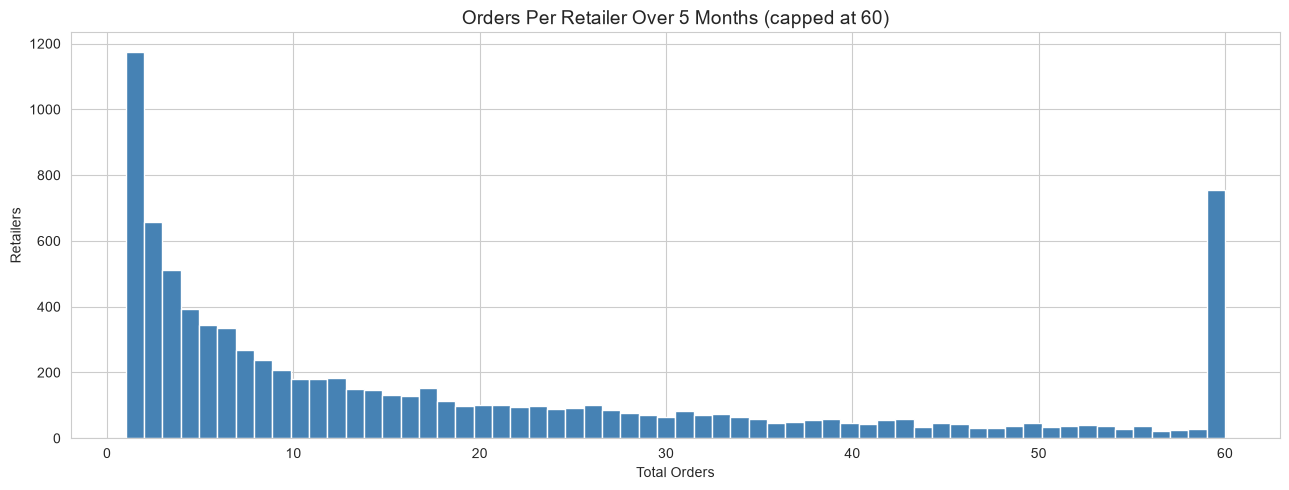

In [11]:
freq = orders.groupby('customerId')['orderNumber'].count()
print('=== ORDERS PER RETAILER (Jan-May) ===')
print(freq.describe().to_string())
print(f'\nOnly 1 order (cold start) : {(freq==1).sum()}')
print(f'2–5 orders                : {((freq>=2)&(freq<=5)).sum()}')
print(f'6+ orders (ML-ready)      : {(freq>=6).sum()}')

plt.figure(figsize=(13,5))
freq.clip(upper=60).hist(bins=60, color='steelblue', edgecolor='white')
plt.title('Orders Per Retailer Over 5 Months (capped at 60)', fontsize=14)
plt.xlabel('Total Orders'); plt.ylabel('Retailers')
plt.tight_layout(); plt.show()

In [12]:
total_retailers = orders['customerId'].nunique()
total_days      = (df['createdAt'].max() - df['createdAt'].min()).days + 1
grid_size       = total_retailers * total_days
positives       = len(orders)
negatives       = grid_size - positives

print(f'Grid size (retailers × days) : {grid_size:,}')
print(f'Positive rows  (ordered=1)   : {positives:,}  ({positives/grid_size*100:.1f}%)')
print(f'Negative rows  (ordered=0)   : {negatives:,}  ({negatives/grid_size*100:.1f}%)')
print(f'Class ratio neg:pos          : {negatives//positives}:1')
print()
print('→ This imbalance is handled via scale_pos_weight in XGBoost (Notebook 3).')

Grid size (retailers × days) : 1,304,640
Positive rows  (ordered=1)   : 177,340  (13.6%)
Negative rows  (ordered=0)   : 1,127,300  (86.4%)
Class ratio neg:pos          : 6:1

→ This imbalance is handled via scale_pos_weight in XGBoost (Notebook 3).
